# QED Amplitude to Squared Amplitude Ablation


In [1]:
#No need of PyG here :)

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def setup_environment() -> tuple[Path, Path]:
    input_dir = Path("/kaggle/input")
    working_dir = Path("/kaggle/working")

    if not input_dir.exists():
        input_dir = Path(".")
        working_dir = Path("outputs/kaggle_custom_qed_amp2sq")

    data_files = list(input_dir.rglob("QED-2-to-2-diag-TreeLevel-*.txt"))
    if not data_files:
        raise FileNotFoundError(f"Could not find data files matching 'QED-2-to-2-diag-TreeLevel-*.txt' under {input_dir}.")
    data_dir = data_files[0].parent

    parser_files = list(input_dir.rglob("custom_qed_amp2sq/parser.py"))
    if not parser_files:
        parser_files = list(input_dir.rglob("src/custom_qed_amp2sq/parser.py"))
    if parser_files:
        package_root = parser_files[0].parent.parent
        if str(package_root) not in sys.path:
            sys.path.insert(0, str(package_root))
    else:
        src_dir = Path.cwd() / "src"
        if src_dir.exists() and str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))

    working_dir.mkdir(parents=True, exist_ok=True)
    return data_dir, working_dir


data_dir, working_dir = setup_environment()
pd.set_option("display.max_colwidth", 240)
plt.rcParams["figure.figsize"] = (8, 4)
print(f"Data directory: {data_dir}")
print(f"Working directory: {working_dir}")


Data directory: /kaggle/input/datasets/nextsmallestml/qed-dataset
Working directory: /kaggle/working


## Target Variants

I keep two decoder targets.

- `factorized`: I simplify the squared amplitude using SymPy and write it as `(charge_factor)*((numerator)/(denominator))`. The model predicts that full symbolic target autoregressively as one postfix sequence under the physics-informed grammar.
- `raw_string`: I decode the original raw SYMBA squared-amplitude string as a postfix token sequence under the same grammar, while keeping rational constants such as `1/6` or `1/2304` intact as single tokens instead of expanding them digit by digit.

The custom encoder is a physics-informed sequence model here. It reads the bounded raw QED amplitude string together with compact canonical global tokens and QED term-summary tokens inside one enriched source sequence, and the decoder cross-attends to that memory while generating the target. 

The symbolic framing I use here follows the basis-oriented amplitude literature cited in the observation cell below, especially Dixon (1996), Del Duca-Dixon-Maltoni (1999), Johansson-Ochirov (2015), and Catani (1998).

While examining the dataset, I noticed that many of the target expressions admit substantial algebraic simplification. This motivated me to study a factorized prediction target for squared amplitudes. The underlying factorization idea is well established in scattering-amplitude physics, but, to the best of my knowledge, its use as a decoder-target design for squared-amplitude prediction has not been explored in prior ML work.



## Input Handling

I start from the raw QED amplitude string and keep a bounded raw token backbone on the source side. I apply bounded index and momentum tokenisation to keep the source manageable. The custom path then augments that same bounded raw sequence with compact QED-specific canonical tokens for the global denominator/channel metadata and term-level Lorentz/Dirac summaries, while the seq2seq baseline reads only the bounded raw amplitude token sequence. Both models decode the squared-amplitude target from the same fixed 80/10/10 split with seed 42.


In [3]:
from statistics import mean

from custom_qed_amp2sq.config import QEDAmp2SqConfig
from custom_qed_amp2sq.factorization import (
    TARGET_VARIANT_FACTORIZED,
    TARGET_VARIANT_RAW_STRING,
    factorize_squared_amplitude,
)
from custom_qed_amp2sq.parser import parse_all_qed
from custom_qed_amp2sq.tokenizer import AmplitudeTokenizer

from custom_qed_amp2sq.train import QEDAmp2SqTrainer

VARIANTS = [('custom', 'custom'), ('seq2seq', 'seq2seq')]
TARGET_SPECS = [
    {
        "target_variant": TARGET_VARIANT_FACTORIZED,
        "decoder_representation": "postfix",
        "use_grammar": True,
    },
    {
        "target_variant": TARGET_VARIANT_RAW_STRING,
        "decoder_representation": "postfix",
        "use_grammar": True,
    },
]
TARGET_SPEC_MAP = {spec["target_variant"]: spec for spec in TARGET_SPECS}
SHARED_SPLIT_SEED = 42
SUMMARY_COLUMNS = [
    "target_variant",
    "variant_name",
    "encoder_variant",
    "max_target_len",
    "split_seed",
    "test_seq_accuracy",
]


def encoded_target_length(expr: str, expression_mode: str) -> int:
    tokenizer = AmplitudeTokenizer(expression_mode=expression_mode)
    length = 2
    for token in tokenizer.tokenize_expr(expr):
        length += 1
    return length


def write_markdown_table(df: pd.DataFrame, path: Path, title: str) -> Path:
    lines = [f"# {title}", ""]
    lines.append("| " + " | ".join(df.columns) + " |")
    lines.append("| " + " | ".join(["---"] * len(df.columns)) + " |")
    for row in df.to_dict(orient="records"):
        rendered = []
        for column in df.columns:
            value = row[column]
            if isinstance(value, float):
                rendered.append(f"{value:.3f}")
            else:
                rendered.append(str(value))
        lines.append("| " + " | ".join(rendered) + " |")
    path.write_text("\n".join(lines) + "\n")
    return path


def target_length_stats(current_data_dir: Path | str, target_variant: str) -> dict[str, float]:
    spec = TARGET_SPEC_MAP[target_variant]
    diagrams = parse_all_qed(current_data_dir)
    targets = [
        factorize_squared_amplitude(diagram.raw_squared, target_variant=target_variant)
        for diagram in diagrams
    ]
    lengths = [
        encoded_target_length(target.sequence_target_text(), spec["decoder_representation"])
        for target in targets
    ]
    return {
        "target_variant": target_variant,
        "decoder_representation": spec["decoder_representation"],
        "min": min(lengths),
        "avg": round(mean(lengths), 2),
        "max": max(lengths),
        "max_with_margin": max(lengths) + 16,
    }


def build_example_tables(current_data_dir: Path | str) -> tuple[pd.DataFrame, pd.DataFrame]:
    diagram = parse_all_qed(current_data_dir)[0]
    raw_squared = diagram.raw_squared
    factorized_target = factorize_squared_amplitude(
        raw_squared,
        target_variant=TARGET_VARIANT_FACTORIZED,
    )
    factorization_example = pd.DataFrame(
        [
            {
                "charge_factor": getattr(factorized_target, "charge_factor"),
                "denominator": factorized_target.denominator.replace("**", "^"),
                "numerator": factorized_target.numerator_infix,
                "factorized_sequence": factorized_target.full_infix,
                "raw_string": factorized_target.raw_string,
            }
        ]
    )

    representation_examples = []
    for spec in TARGET_SPECS:
        target = factorize_squared_amplitude(
            raw_squared,
            target_variant=spec["target_variant"],
        )
        representation_examples.append(
            {
                "target_variant": spec["target_variant"],
                "decoder_representation": spec["decoder_representation"],
                "use_grammar": spec["use_grammar"],
                "sequence_target": target.sequence_target_text(),
            }
        )
    return factorization_example, pd.DataFrame(representation_examples)


def observation_summary(current_data_dir: Path | str) -> pd.DataFrame:
    diagrams = parse_all_qed(current_data_dir)
    targets = [
        factorize_squared_amplitude(diagram.raw_squared, target_variant=TARGET_VARIANT_FACTORIZED)
        for diagram in diagrams
    ]
    factors = sorted({getattr(target, "charge_factor") for target in targets})
    denominators = sorted({target.denominator.replace("**", "^") for target in targets})
    return pd.DataFrame(
        [
            {
                "num_samples": len(targets),
                "unique_charge_factors": len(factors),
                "unique_denominators": len(denominators),
            }
        ]
    )


def build_variant_config(
    current_data_dir: Path,
    current_working_dir: Path,
    *,
    target_variant: str,
    variant_name: str,
    encoder_variant: str,
    max_target_len: int,
):
    spec = TARGET_SPEC_MAP[target_variant]
    config = QEDAmp2SqConfig()
    config.data.data_dir = str(current_data_dir)
    config.data.target_variant = target_variant
    config.output_dir = str(current_working_dir / target_variant / variant_name)
    config.experiment_name = f"{target_variant}_{variant_name}"

    config.training.max_epochs = 500 if target_variant == TARGET_VARIANT_RAW_STRING else 300
    config.training.stop_on_val_exact = None
    config.training.stop_on_test_exact = None
    config.training.batch_size = 8
    config.training.learning_rate = 3e-4
    config.training.weight_decay = 1e-5
    config.training.warmup_epochs = 10
    config.training.min_lr = 1e-6
    config.training.gradient_clip = 1.0
    config.training.seed = SHARED_SPLIT_SEED
    config.training.num_workers = 2
    config.training.log_every_n_steps = 10

    config.model.hidden_dim = 192
    config.model.stream_dim = 128
    config.model.graph_dim = 192
    config.model.num_mp_layers = 4
    config.model.num_heads = 8
    config.model.dropout = 0.1
    config.model.max_src_term_len = 192
    config.model.max_src_terms = 32
    config.model.max_flat_src_len = 3072
    config.model.max_tgt_seq_len = max_target_len
    config.model.max_gen_len = max_target_len
    config.model.dec_d_model = 384
    config.model.dec_nhead = 8
    config.model.dec_layers = 6
    config.model.dec_dim_ff = 1024
    config.model.decoder_representation = spec["decoder_representation"]
    config.model.use_grammar = spec["use_grammar"]
    config.model.encoder_variant = encoder_variant
    return config


def _clean_curve(values):
    return [float("nan") if value is None else float(value) for value in values]


def plot_suite_losses(target_variant: str, results_df: pd.DataFrame, histories: dict[str, dict]) -> Path:
    plot_dir = working_dir / "loss_curves"
    plot_dir.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, len(results_df), figsize=(6 * len(results_df), 4), squeeze=False)
    axes = axes[0]
    for ax, row in zip(axes, results_df.to_dict(orient="records")):
        history = histories[row["variant_name"]]
        epochs = list(range(1, len(history["train_loss"]) + 1))
        ax.plot(epochs, _clean_curve(history["train_loss"]), label="train loss")
        ax.plot(epochs, _clean_curve(history["val_loss"]), label="val loss")
        ax.set_title(f"{row['encoder_variant']} ({target_variant})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.tight_layout()
    path = plot_dir / f"{target_variant}_loss_curves.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def plot_suite_accuracies(target_variant: str, results_df: pd.DataFrame, histories: dict[str, dict]) -> Path:
    plot_dir = working_dir / "accuracy_curves"
    plot_dir.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, len(results_df), figsize=(6 * len(results_df), 4), squeeze=False)
    axes = axes[0]
    for ax, row in zip(axes, results_df.to_dict(orient="records")):
        history = histories[row["variant_name"]]
        epochs = list(range(1, len(history["val_seq_accuracy"]) + 1))
        ax.plot(epochs, _clean_curve(history["val_seq_accuracy"]), label="val seq accuracy")
        ax.set_title(f"{row['encoder_variant']} ({target_variant})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation sequence accuracy")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.tight_layout()
    path = plot_dir / f"{target_variant}_accuracy_curves.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def run_suite(target_variant: str) -> tuple[pd.DataFrame, dict[str, dict]]:
    target_len = max(target_length_stats(data_dir, target_variant)["max_with_margin"], 128)
    results = []
    histories = {}
    for variant_name, encoder_variant in VARIANTS:
        config = build_variant_config(
            data_dir,
            working_dir,
            target_variant=target_variant,
            variant_name=variant_name,
            encoder_variant=encoder_variant,
            max_target_len=target_len,
        )
        trainer = QEDAmp2SqTrainer(config)
        history = trainer.train()
        metrics = trainer.evaluate()
        histories[variant_name] = history
        results.append(
            {
                "target_variant": target_variant,
                "variant_name": variant_name,
                "encoder_variant": encoder_variant,
                "max_target_len": target_len,
                "split_seed": SHARED_SPLIT_SEED,
                "test_seq_accuracy": metrics["test_seq_accuracy"],
                "test_loss": metrics["test_loss"],
            }
        )
    return pd.DataFrame(results), histories


## Example

QED squared-amplitude sample decomposes into its `charge_factor`, denominator, numerator, and the two sequence targets I actually compare.


In [4]:
example_factor_df, example_target_df = build_example_tables(data_dir)
display(example_factor_df)
display(example_target_df)


  Parsed QED-2-to-2-diag-TreeLevel-0.txt: 54 diagrams
  Parsed QED-2-to-2-diag-TreeLevel-1.txt: 50 diagrams
  Parsed QED-2-to-2-diag-TreeLevel-2.txt: 46 diagrams
  Parsed QED-2-to-2-diag-TreeLevel-3.txt: 42 diagrams
  Parsed QED-2-to-2-diag-TreeLevel-4.txt: 38 diagrams
  Parsed QED-2-to-2-diag-TreeLevel-5.txt: 34 diagrams
  Parsed QED-2-to-2-diag-TreeLevel-6.txt: 30 diagrams
  Parsed QED-2-to-2-diag-TreeLevel-7.txt: 26 diagrams
  Parsed QED-2-to-2-diag-TreeLevel-8.txt: 22 diagrams
  Parsed QED-2-to-2-diag-TreeLevel-9.txt: 18 diagrams
Total QED diagrams: 360


,charge_factor,denominator,numerator,factorized_sequence,raw_string
0,8,(2*m_e^2 + reg_prop + 2*s_12)^2,2*m_e^2*m_mu^2 + m_e^2*s_34 + m_mu^2*s_12 + s_13*s_24 + s_14*s_23,(8)*((2*m_e^2*m_mu^2 + m_e^2*s_34 + m_mu^2*s_12 + s_13*s_24 + s_14*s_23)/((2*m_e^2 + reg_prop + 2*s_12)^2)),1/4*e^4*(16*m_e^2*m_mu^2 + 8*m_mu^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_e^2*s_34)*(m_e^2 + s_12 + 1/2*reg_prop)^(-2)


,target_variant,decoder_representation,use_grammar,sequence_target
0,factorized,postfix,True,(8)*((2*m_e^2*m_mu^2 + m_e^2*s_34 + m_mu^2*s_12 + s_13*s_24 + s_14*s_23)/((2*m_e^2 + reg_prop + 2*s_12)^2))
1,raw_string,postfix,True,1/4*e^4*(16*m_e^2*m_mu^2 + 8*m_mu^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_e^2*s_34)*(m_e^2 + s_12 + 1/2*reg_prop)^(-2)


## Target 




In [5]:
target_stats = pd.DataFrame(
    [target_length_stats(data_dir, spec["target_variant"]) for spec in TARGET_SPECS]
)
display(target_stats)


,target_variant,decoder_representation,min,avg,max,max_with_margin
0,factorized,postfix,41,44.70,47,63
1,raw_string,postfix,58,71.52,92,108


## Factorized Runs


## Monitoring Policy

For the factorized target, I decode only the validation split during training, so the accuracy curve shows validation sequence accuracy only. I select the best checkpoint by highest validation sequence accuracy with validation loss as the tie-breaker.

For the raw-string target, I decode only the validation split every 20 epochs. I select the best checkpoint by highest validation sequence accuracy with validation loss as the tie-breaker, and I then report exact test sequence accuracy from that best checkpoint. This keeps raw-string monitoring manageable while still aligning model selection with the final exact-match objective.

## Factorised Runs

Using device: cuda


/kaggle/input/datasets/nextsmallestml/qed-amtosquare/custom_qed_amp2sq/encoder.py:86: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)



  QED Amp2Sq Training: factorized_custom
  Encoder: custom
  Source view: physics-tagged QED amplitude sequence
  Target variant: factorized
  Decoder representation: postfix
  Grammar constrained: True
  Train/val/test: 288/36/36
  Epochs: 300
  Batch size: 8
  Learning rate: 0.0003
  Device: cuda

Epoch 0001 | train 5.9764 | val 0.9284 / seq 0.000 | improved | 9.4s
Epoch 0002 | train 0.7364 | val 0.5453 / seq 0.000 | improved | 18.1s
Epoch 0003 | train 0.5385 | val 0.3553 / seq 0.000 | improved | 26.7s
Epoch 0004 | train 0.3855 | val 0.2248 / seq 0.028 | improved | 35.4s
Epoch 0005 | train 0.2622 | val 0.1471 / seq 0.139 | improved | 44.3s
Epoch 0010 | train 0.0908 | val 0.0775 / seq 0.500 | improved | 87.3s
Epoch 0020 | train 0.0340 | val 0.0865 / seq 0.611 | 172.4s
Epoch 0030 | train 0.0191 | val 0.0528 / seq 0.778 | 256.5s
Epoch 0040 | train 0.0171 | val 0.0143 / seq 0.917 | 340.1s
Epoch 0050 | train 0.0118 | val 0.0322 / seq 0.889 | 424.7s
Epoch 0060 | train 0.0099 | val 0.0038 

,target_variant,variant_name,encoder_variant,max_target_len,split_seed,test_seq_accuracy
0,factorized,custom,custom,128,42,1.0
1,factorized,seq2seq,seq2seq,128,42,1.0


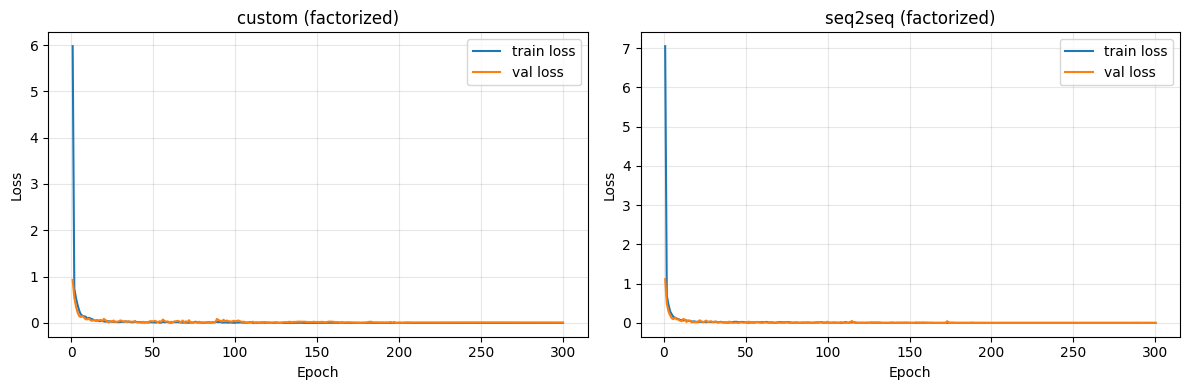

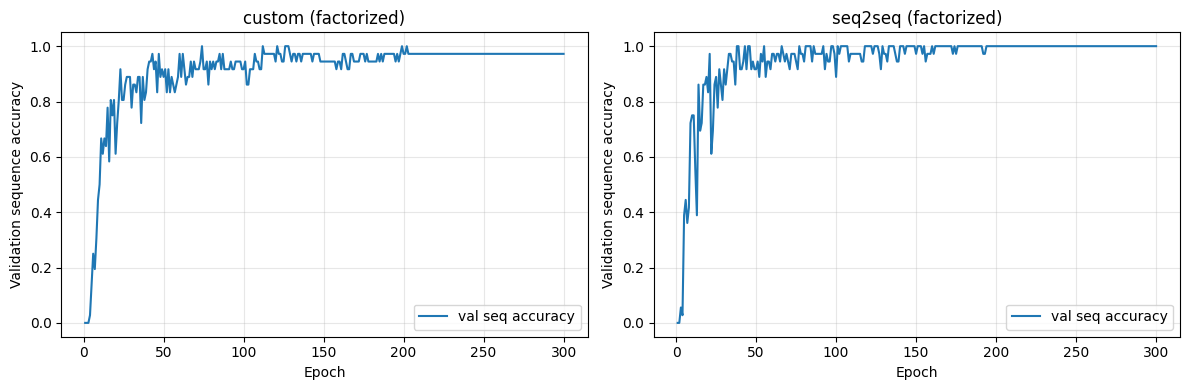

PosixPath('/kaggle/working/accuracy_curves/factorized_accuracy_curves.png')

In [6]:
factorized_results, factorized_histories = run_suite(TARGET_VARIANT_FACTORIZED)
display(factorized_results[SUMMARY_COLUMNS])
plot_suite_losses(TARGET_VARIANT_FACTORIZED, factorized_results, factorized_histories)
plot_suite_accuracies(TARGET_VARIANT_FACTORIZED, factorized_results, factorized_histories)


## Raw String Runs


Using device: cuda

  QED Amp2Sq Training: raw_string_custom
  Encoder: custom
  Source view: physics-tagged QED amplitude sequence
  Target variant: raw_string
  Decoder representation: postfix
  Grammar constrained: True
  Train/val/test: 288/36/36
  Epochs: 500
  Batch size: 8
  Learning rate: 0.0003
  Device: cuda



/kaggle/input/datasets/nextsmallestml/qed-amtosquare/custom_qed_amp2sq/encoder.py:86: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 0001 | train 7.5267 | val 0.8001 | 6.3s
Epoch 0002 | train 0.6830 | val 0.4712 | 12.7s
Epoch 0003 | train 0.4600 | val 0.3238 | 19.1s
Epoch 0004 | train 0.3218 | val 0.2076 | 25.4s
Epoch 0005 | train 0.2208 | val 0.1719 | 31.8s
Epoch 0010 | train 0.0674 | val 0.0724 | 63.7s
Epoch 0020 | train 0.0257 | val 0.0091 / seq 0.861 | improved | 131.5s
Epoch 0030 | train 0.0078 | val 0.0197 | 195.1s
Epoch 0040 | train 0.0037 | val 0.0154 / seq 0.833 | 262.6s
Epoch 0050 | train 0.0116 | val 0.0131 | 326.1s
Epoch 0060 | train 0.0133 | val 0.0078 / seq 0.917 | improved | 393.6s
Epoch 0070 | train 0.0123 | val 0.0148 | 457.0s
Epoch 0080 | train 0.0059 | val 0.0185 / seq 0.806 | 524.2s
Epoch 0090 | train 0.0054 | val 0.0066 | 587.6s
Epoch 0100 | train 0.0087 | val 0.0144 / seq 0.833 | 654.6s
Epoch 0110 | train 0.0063 | val 0.0026 | 718.0s
Epoch 0120 | train 0.0054 | val 0.0050 / seq 0.972 | improved | 785.6s
Epoch 0130 | train 0.0097 | val 0.0094 | 849.1s
Epoch 0140 | train 0.0032 | val 0.0108

,target_variant,variant_name,encoder_variant,max_target_len,split_seed,test_seq_accuracy
0,raw_string,custom,custom,128,42,0.972222
1,raw_string,seq2seq,seq2seq,128,42,0.916667


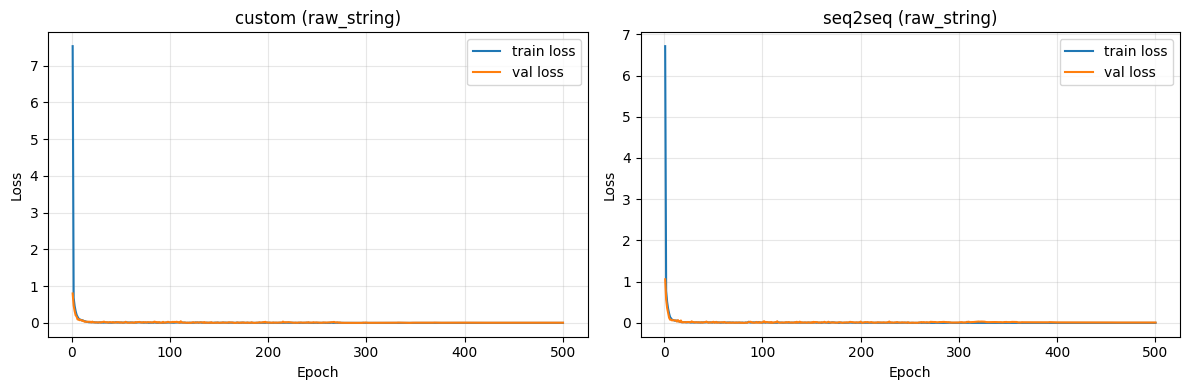

PosixPath('/kaggle/working/loss_curves/raw_string_loss_curves.png')

In [7]:
raw_results, raw_histories = run_suite(TARGET_VARIANT_RAW_STRING)
display(raw_results[SUMMARY_COLUMNS])
plot_suite_losses(TARGET_VARIANT_RAW_STRING, raw_results, raw_histories)


## Final Summary


In [8]:
final_summary_df = pd.concat([factorized_results, raw_results], ignore_index=True)
summary_small = final_summary_df[SUMMARY_COLUMNS]
summary_json = working_dir / "ablation_summary_all.json"
summary_md = working_dir / "ablation_summary_all.md"
summary_small.to_json(summary_json, orient="records", indent=2)
write_markdown_table(summary_small, summary_md, "Final Summary")
display(summary_small)
print(f"Saved summary to {summary_json}")
print(f"Saved markdown summary to {summary_md}")


,target_variant,variant_name,encoder_variant,max_target_len,split_seed,test_seq_accuracy
0,factorized,custom,custom,128,42,1.000000
1,factorized,seq2seq,seq2seq,128,42,1.000000
2,raw_string,custom,custom,128,42,0.972222
3,raw_string,seq2seq,seq2seq,128,42,0.916667


Saved summary to /kaggle/working/ablation_summary_all.json
Saved markdown summary to /kaggle/working/ablation_summary_all.md


## Observation

What I notice here is that the audited tree-level QED 2-to-2 dataset closes to a small finite family of simplified `charge_factor` terms and denominator forms. 

The audited `charge_factor` classes are:

```text
128/81
32/81
32/9
4
4/81
64/81
8
8/81
8/9
```

The audited denominator classes are:

```text
(2*m_b^2 + reg_prop + 2*s_12)^2
(2*m_c^2 + reg_prop + 2*s_12)^2
(2*m_c^2 + reg_prop - 2*s_13)^2
(2*m_d^2 + reg_prop + 2*s_12)^2
(2*m_d^2 + reg_prop - 2*s_13)^2
(2*m_e^2 + reg_prop + 2*s_12)^2
(2*m_e^2 + reg_prop - 2*s_13)^2
(2*m_mu^2 + reg_prop + 2*s_12)^2
(2*m_mu^2 + reg_prop - 2*s_13)^2
(2*m_s^2 + reg_prop + 2*s_12)^2
(2*m_s^2 + reg_prop - 2*s_13)^2
(2*m_t^2 + reg_prop + 2*s_12)^2
(2*m_t^2 + reg_prop - 2*s_13)^2
(2*m_tt^2 + reg_prop + 2*s_12)^2
(2*m_tt^2 + reg_prop - 2*s_13)^2
(2*m_u^2 + reg_prop + 2*s_12)^2
(2*m_u^2 + reg_prop - 2*s_13)^2
(reg_prop + 2*s_12)^2
(reg_prop - 2*s_13)^2
(reg_prop - 2*s_23)^2
```

For the QED notebooks, the analogous closure is simpler because the non-Abelian color algebra is replaced by products of squares of external electric charges. I treat that as a finite charge-basis observation for the audited corpus and let the factorized model learn it autoregressively through the factorized target sequence itself.

If I extend this later, the interesting question is how these observed finite families change once I move beyond 2-to-2 tree level, allow more external legs, or include loops. 

References:
- [L. Dixon, *Calculating Scattering Amplitudes Efficiently* (1996)](https://arxiv.org/abs/hep-ph/9601359)
- [V. Del Duca, L. Dixon, F. Maltoni, *New Color Decompositions for Gauge Amplitudes at Tree and Loop Level* (1999)](https://arxiv.org/abs/hep-ph/9910563)
- [H. Johansson, A. Ochirov, *Color-Kinematics Duality for QCD Amplitudes* (2015)](https://arxiv.org/abs/1507.00332)
- [S. Catani, *The Singular Behaviour of QCD Amplitudes at Two-Loop Order* (1998)](https://arxiv.org/abs/hep-ph/9802439)


In [9]:
observation_summary_df = observation_summary(data_dir)
observation_json = working_dir / "observation_summary.json"
observation_md = working_dir / "observation_summary.md"
observation_summary_df.to_json(observation_json, orient="records", indent=2)
write_markdown_table(observation_summary_df, observation_md, "Observation Summary")
display(observation_summary_df)
print(f"Saved observation summary to {observation_json}")
print(f"Saved observation markdown to {observation_md}")


,num_samples,unique_charge_factors,unique_denominators
0,360,9,20


Saved observation summary to /kaggle/working/observation_summary.json
Saved observation markdown to /kaggle/working/observation_summary.md


## Thank you!
Please mail me at sreenandan.shashidharan@gmail.com or at 24JE0701@iitism.ac.in if anything is amiss. I sincerely apologise in advance. 